In [1]:
import sys
import os
sys.path.insert(0, '/nfs/turbo/ihpi-cms/Wiens_ML/users/muskaan/scamer-simulations')


In [2]:
# Data stitching (SCaMEr) using real medicare beneficiary covariates
# Randomizing most of the causal effects within the graph to ensure our method works regardless of what those values are
# 1. Vary True Upcoding Rate
# 2. Vary True Downcoding Rate

import pandas as pd
import numpy as np
from models import cmre, nmre, ndee, ocsvm_medicare
from models_ds import cmre_ds
from plots import plot_appendix, plot_main_paper
import copy
import pickle
from scipy.special import expit # expit applies sigmoid to a Series
import matplotlib.pyplot as plt
import gc

# muskaan runs this inside sim_env

In [3]:
RESULTS_DIR = 'sim_medicare_data_randomized_results_2'

# Simulation 6 Experiments

In [4]:
def generate_sgc_datasets(true_upcoding_rate, true_downcoding_rate):

    # Load dataset
    df = pd.read_pickle('datasets/medicare_data_subset.pkl')
    df = df.sample(frac=1).reset_index(drop=True)
    df = df.dropna()

    df = df.rename(columns={
        'AGE_AT_END_REF_YR_18': 'AGE',
        'SEX_IDENT_CD_18': 'SEX',
        'BENE_RACE_CD_18_1': 'RACE'
    })

    # Drop columns that are not needed
    df = df[['SEX', 'RACE', 'AGE']]

    # Min-max scale the data
    df['AGE'] = (df['AGE'] - df['AGE'].min()) / (df['AGE'].max() - df['AGE'].min())

    # Generate random coefficients
    values = np.array([0.0, 0.05, 0.1, 0.15, 0.2])

    effect_of_sex_on_agent = np.random.choice(values)
    effect_of_race_sex_on_hcc_prob = np.random.choice(values)
    effect_of_age_on_hcc_prob = np.random.choice(values)
    effect_of_agent_1_on_hcc_prob = np.random.choice(values)
    effect_of_agent_0_on_hcc_prob = np.random.choice(values)
    effect_of_race_on_default = np.random.choice(values)
    effect_of_sex_on_default = np.random.choice(values)
    effect_of_age_on_default = np.random.choice(values)
    effect_of_hcc_on_default = np.random.choice(values)
    
    # Use sex as selection bias
    agent_prob = 0.30  + (1-df['SEX']) * effect_of_sex_on_agent
    df['AGENT'] = np.random.binomial(1, expit(agent_prob), len(df))
    
    # Generate hcc variable
    hcc_prob = 0.18 \
                    + df['RACE'] * df['SEX'] * effect_of_race_sex_on_hcc_prob \
                    + np.square(df['AGE']) * effect_of_age_on_hcc_prob \
                    + df['AGENT'] * effect_of_agent_1_on_hcc_prob + (1-df['AGENT']) * effect_of_agent_0_on_hcc_prob
    df['HCC'] = np.random.binomial(1, expit(hcc_prob), len(df))

    # Generate default variable (Y)
    default_prob = 0.10 \
                    + df['RACE'] * effect_of_race_on_default \
                    + df['SEX'] * effect_of_sex_on_default \
                    + np.square(df['AGE']) * effect_of_age_on_default \
                    + df['HCC'] * effect_of_hcc_on_default
    df['DEFAULT'] = np.random.binomial(1, expit(default_prob), len(df))

    # Strategically misreport the dataset (misreported hcc status)
    prob_required_for_upcoding_rate = ((hcc_prob / (1-true_upcoding_rate)) - hcc_prob) / (1 - hcc_prob)
    prob_required_for_downcoding_rate = (((1 - hcc_prob) / (1-true_downcoding_rate)) - (1 - hcc_prob)) / hcc_prob
    
    if (prob_required_for_downcoding_rate < 0).any():
        print("downcoding contains values < 0")

    # Check for any value > 1
    if (prob_required_for_downcoding_rate > 1).any():
        print("downcoding contains values > 1")
    
    df['HCC'] = (df['HCC'] + df['AGENT']*(1-df['HCC']) * np.random.binomial(1, prob_required_for_upcoding_rate,  len(df))
                        - df['HCC']*(1-df['AGENT']) * np.random.binomial(1, prob_required_for_downcoding_rate, len(df)))

    return df

# Results for semi-synthetic loan experiments

### Estimate MR given different True Misreporting Rates

In [5]:
num_sims = 20
true_upcoding_rates = [0.0, 0.05, 0.10, 0.15, 0.20]
true_downcoding_rate = 0.10

# Dataframes to keep track of results
cmre_ds_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
cmre_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
nmre_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
ndee_all_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
ndee_no_s_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
ocsvm_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
# mr and true_mr here refer to the rate of upcoding (model's estimate of it and its true value, respectively)

# Perform a few simulations for each method
for sim in range(num_sims):
    # Set the random seed
    np.random.seed(sim)
    
    print(sim)
    
    for true_mr in true_upcoding_rates:
        # Generate dataset for simulation
        df = generate_sgc_datasets(true_mr, true_downcoding_rate)

        normal_dataset = df[df['AGENT'] == 0] # TM
        strategic_dataset = df[df['AGENT'] == 1] # MA
        
        # Get misreporting rates and keep track of results
        mr = cmre_ds('HCC', 'DEFAULT', ['SEX', 'RACE', 'AGE'], normal_dataset, strategic_dataset)
        cmre_ds_loan_results_mr_df_normal.loc[len(cmre_ds_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = cmre('HCC', 'DEFAULT', ['SEX', 'RACE', 'AGE'], normal_dataset, strategic_dataset)
        cmre_loan_results_mr_df_normal.loc[len(cmre_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = nmre('HCC', 'DEFAULT', normal_dataset, strategic_dataset)
        nmre_loan_results_mr_df_normal.loc[len(nmre_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = ndee('AGENT', 'HCC', ['SEX', 'RACE', 'AGE'], df)
        ndee_all_loan_results_mr_df_normal.loc[len(ndee_all_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = ndee('AGENT', 'HCC', ['AGE'], df)
        ndee_no_s_loan_results_mr_df_normal.loc[len(ndee_no_s_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = ocsvm_medicare(normal_dataset, strategic_dataset)
        ocsvm_loan_results_mr_df_normal.loc[len(ocsvm_loan_results_mr_df_normal)] = [sim, true_mr, mr]
        
        del df
        gc.collect()
        

# Get mean and std for each causal effect
cmre_ds_loan_results_mr_df_normal = cmre_ds_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
cmre_loan_results_mr_df_normal = cmre_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
nmre_loan_results_mr_df_normal = nmre_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
ndee_all_loan_results_mr_df_normal = ndee_all_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
ndee_no_s_loan_results_mr_df_normal = ndee_no_s_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
ocsvm_loan_results_mr_df_normal = ocsvm_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [6]:
# Save info
loan_list_mr_normal = [cmre_ds_loan_results_mr_df_normal,
                       cmre_loan_results_mr_df_normal,
                       nmre_loan_results_mr_df_normal,
                       ndee_all_loan_results_mr_df_normal,
                       ndee_no_s_loan_results_mr_df_normal,
                       ocsvm_loan_results_mr_df_normal]
with open(f'{RESULTS_DIR}/loan_list_mr_normal.pkl', 'wb') as f:
    pickle.dump(loan_list_mr_normal, f)

### Estimate MR given different Downcoding Rates

In [7]:
num_sims = 20
true_upcoding_rate = 0.20
true_downcoding_rates = [0, 0.05, 0.10, 0.15]

# Dataframes to keep track of results
cmre_ds_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
cmre_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
nmre_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
ndee_all_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
ndee_no_s_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
ocsvm_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
# true_dr is the true rate of downcoding

# Perform a few simulations for each method
for sim in range(num_sims):
    # Set the random seed
    np.random.seed(sim)
    
    for true_downcoding_rate in true_downcoding_rates:

        print(true_downcoding_rate)
        # Generate dataset for simulation
        df = generate_sgc_datasets(true_upcoding_rate, true_downcoding_rate)

        normal_dataset = df[df['AGENT'] == 0] # TM
        strategic_dataset = df[df['AGENT'] == 1] # MA
        
        # Get misreporting rates and keep track of results
        mr = cmre_ds('HCC', 'DEFAULT', ['SEX', 'RACE', 'AGE'], normal_dataset, strategic_dataset)
        cmre_ds_loan_results_dr_df_normal.loc[len(cmre_ds_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = cmre('HCC', 'DEFAULT', ['SEX', 'RACE', 'AGE'], normal_dataset, strategic_dataset)
        cmre_loan_results_dr_df_normal.loc[len(cmre_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = nmre('HCC', 'DEFAULT', normal_dataset, strategic_dataset)
        nmre_loan_results_dr_df_normal.loc[len(nmre_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = ndee('AGENT', 'HCC', ['SEX', 'RACE', 'AGE'], df)
        ndee_all_loan_results_dr_df_normal.loc[len(ndee_all_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = ndee('AGENT', 'HCC', ['AGE'], df)
        ndee_no_s_loan_results_dr_df_normal.loc[len(ndee_no_s_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = ocsvm_medicare(normal_dataset, strategic_dataset)
        ocsvm_loan_results_dr_df_normal.loc[len(ocsvm_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]
        

# Get mean and std for each causal effect
cmre_ds_loan_results_dr_df_normal = cmre_ds_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
cmre_loan_results_dr_df_normal = cmre_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
nmre_loan_results_dr_df_normal = nmre_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
ndee_all_loan_results_dr_df_normal = ndee_all_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
ndee_no_s_loan_results_dr_df_normal = ndee_no_s_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
ocsvm_loan_results_dr_df_normal = ocsvm_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()

0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15
0
0.05
0.1
0.15


In [8]:
# Save info
loan_list_dr_normal = [cmre_ds_loan_results_dr_df_normal,
                       cmre_loan_results_dr_df_normal,
                       nmre_loan_results_dr_df_normal,
                       ndee_all_loan_results_dr_df_normal,
                       ndee_no_s_loan_results_dr_df_normal,
                       ocsvm_loan_results_dr_df_normal]
with open(f'{RESULTS_DIR}/loan_list_dr_normal.pkl', 'wb') as f:
    pickle.dump(loan_list_dr_normal, f)

# Create plots

In [9]:
# Load lists
with open(f'{RESULTS_DIR}/loan_list_mr_normal.pkl', 'rb') as f:
    loan_list_mr_normal = pickle.load(f)
with open(f'{RESULTS_DIR}/loan_list_dr_normal.pkl', 'rb') as f:
    loan_list_dr_normal = pickle.load(f)

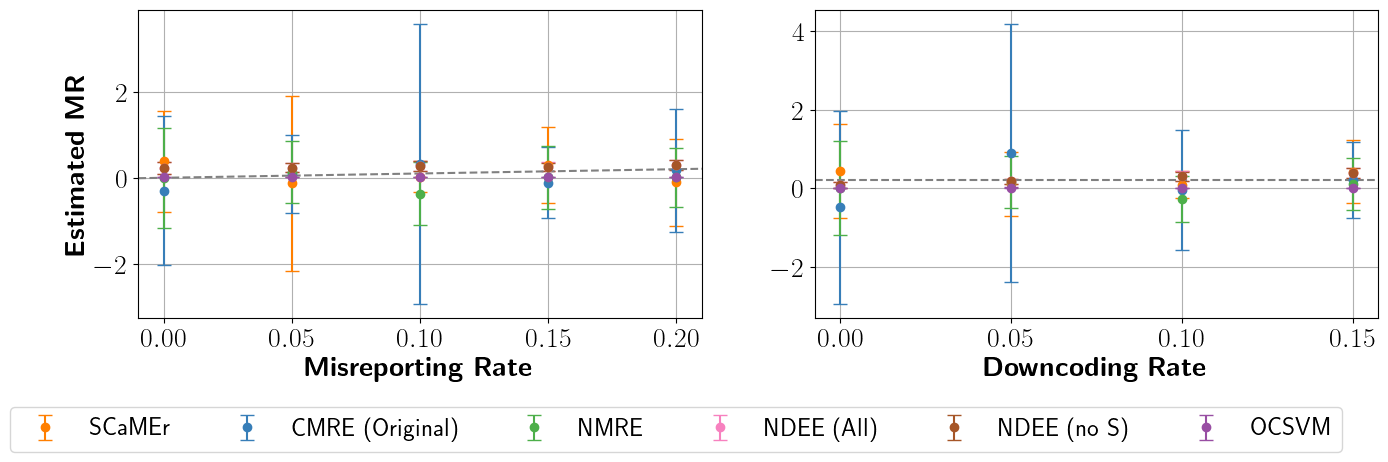

In [10]:
# Create and show plot
synth_list = [loan_list_mr_normal, loan_list_dr_normal]
synth_mr_list = [0.2, 0.2]
label_list = ['SCaMEr', 'CMRE (Original)', 'NMRE', 'NDEE (All)', 'NDEE (no S)', 'OCSVM']
x_var_list = ['true_mr', 'true_dr']
x_label_list = [r'\textbf{Misreporting Rate}', r'\textbf{Downcoding Rate}']
y_label = r'\textbf{Estimated MR}'

plt = plot_appendix(synth_list,
                label_list,
                synth_mr_list,
                x_var_list,
                x_label_list,
                y_label)


# plt.show()
plt.savefig(f'{RESULTS_DIR}/medicare_sim_results.pdf', dpi=600, bbox_inches='tight')

In [15]:
# # Create and show plot
# indices = [0,1,2,4]
# # loan_list_sa_normal_small = [loan_list_sa_normal[i] for i in indices]
# # loan_list_ce_normal_small = [loan_list_ce_normal[i] for i in indices]
# loan_list_mr_normal_small = [loan_list_mr_normal[i] for i in indices]
# synth_list = [loan_list_mr_normal_small] # [loan_list_sa_normal_small, loan_list_ce_normal_small, loan_list_mr_normal_small]
# synth_mr_list = [0.2] # [0.2, 0.2, 0.2]
# label_list = [r'\textbf{CMRE (Ours)}', r'\textbf{NMRE}', r'\textbf{NDEE}', r'\textbf{OC-SVM}']
# x_var_list = ['true_mr'] # ['sa', 'ce', 'true_mr']
# x_label_list = [r'\textbf{Misreporting Rate}'] # [r'\textbf{Causal Effect of $A$ on $X^{*}$}', r'\textbf{Causal Effect of $X^{*}$ on $Y$}', r'\textbf{Misreporting Rate}']
# y_label = r'\textbf{Estimated MR}'

# plt = plot_main_paper(synth_list,
#                 label_list,
#                 synth_mr_list,
#                 x_var_list,
#                 x_label_list,
#                 y_label)

# plt.savefig(f'{RESULTS_DIR}/simulation_1_main_plot.pdf', dpi=600, bbox_inches='tight')